<a href="https://colab.research.google.com/github/Rohan1-tech/customer-behavior-analysis-Dashboard/blob/main/Customer_Shopping_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**


A retail company aims to gain deeper insights into customer shopping behavior to improve sales performance, enhance customer satisfaction, and increase long-term loyalty. With growing variations in purchasing patterns across different demographics, product categories, and sales channels (online vs. offline), the company faces challenges in understanding what truly drives customer decisions.

The business wants to identify key factors such as product ratings, pricing, discounts, seasonal trends, and payment preferences that influence purchasing behavior and repeat transactions. However, the available data is unstructured and lacks clear insights.

# **Objective**


The objective of this project is to analyze customer transaction data to:

* Identify purchasing patterns and trends
* Understand factors influencing customer decisions
* Segment customers based on behavior
* Evaluate the impact of shipping type, reviews, and pricing
* Generate actionable insights to improve marketing and product strategies

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Data/customer_shopping_behavior.csv')


**Basic Understanding**

In [4]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [6]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [8]:
df.shape

(3900, 18)

In [9]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [10]:
# Handle missing values

df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [11]:
# Perfrom Mean Imputation

df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean())


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# removes spaces, converts to lowercase

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [14]:
# rename column purchase_amount_(usd) with  purchase_amount

df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'}, inplace=True)

In [15]:
# create new group

labels = ['young_adult', 'adult', 'mid_age', 'senior']
df['Age_Group'] = pd.qcut(df['age'], q=4, labels=labels)

**EDA (Exploratory Data Analysis)**

**1. Purchase Amount Distribution (Histogram)**

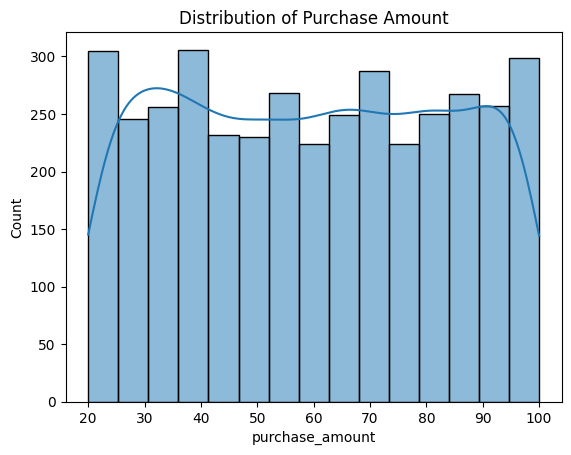

In [16]:
sns.histplot(df['purchase_amount'], kde=True)
plt.title("Distribution of Purchase Amount")
plt.show()

**1. Why we use it:**

* To understand how values are spread
* Detect skewness (low vs high spending)


**2. What Insight we Found:**

Most purchase amounts are concentrated in the lower range, indicating a large number of low-value transactions with fewer high-value purchases.

**2. Category-wise Purchases (Countplot)**

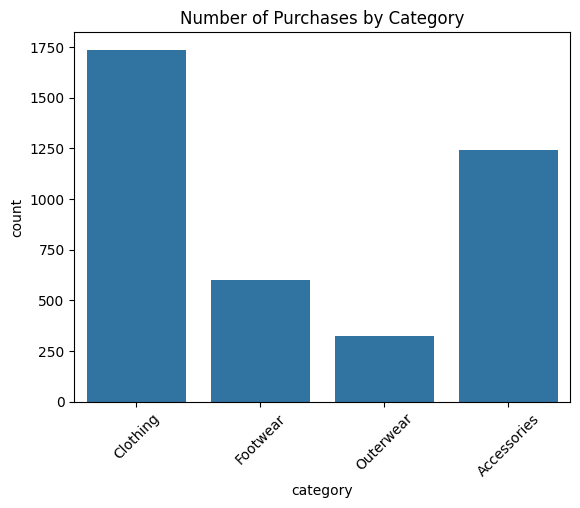

In [17]:
sns.countplot(x='category', data=df)
plt.xticks(rotation=45)
plt.title("Number of Purchases by Category")
plt.show()

**1. Why we use it:**

* To see most popular category

**2. What Insight we Found:**

Category X has the highest number of purchases, indicating strong customer preference for this segment.

**3. Gender vs Purchase Amount (Boxplot)**

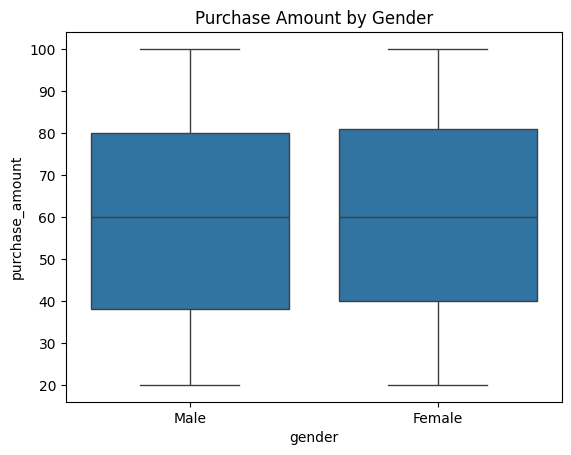

In [18]:
sns.boxplot(x='gender', y='purchase_amount', data=df)
plt.title("Purchase Amount by Gender")
plt.show()

**1. Why we use it:**

* Compare spending between groups
* Detect outliers


**2. What Insight we Found:**


One gender shows slightly higher median spending, suggesting differences in purchasing behavior.

**4. Age vs Purchase Amount (Scatterplot)**



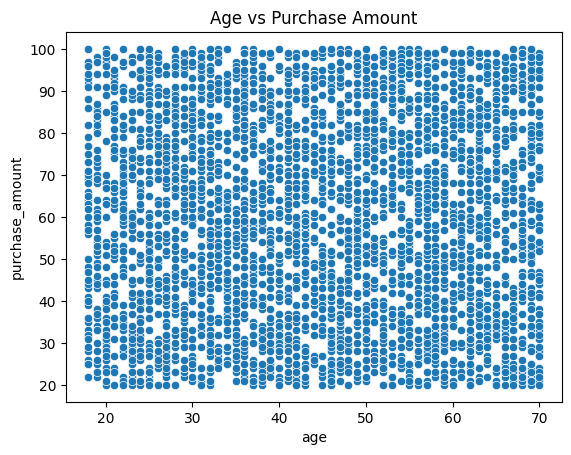

In [19]:
sns.scatterplot(x='age', y='purchase_amount', data=df)
plt.title("Age vs Purchase Amount")
plt.show()

**1. Why we use it:**

* Check relationship between age & spending

**2. What Insight we Found:**

* There is no strong linear relationship between age and purchase amount, indicating spending behavior is not heavily age-dependent

**5. Payment Method Distribution (Countplot)**

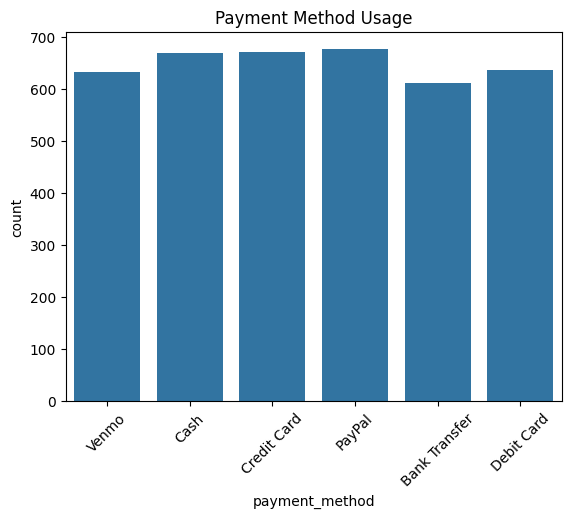

In [20]:
sns.countplot(x='payment_method', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method Usage")
plt.show()

**1. Why we use it:**

Understand customer payment preference

**2. What Insight we Found:**

Most customers prefer method X, highlighting its dominance as the primary payment option.

**Push Your Project Data into SQL**

In [21]:
df.to_csv("final_data.csv", index=False)

In [22]:
from google.colab import files
files.download("final_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>